<a href="https://colab.research.google.com/github/unluckycharm1/google-colab/blob/main/Mangaron_activity_01_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [100]:
iris = load_iris()
print(iris.feature_names)
# ['sepal length(cm)', 'sepal width (cm)', 'petal length(cm)', 'petal width(cm)']

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [101]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [102]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df['species'] = iris.target_names[iris.target]
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [103]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 150
Number of columns: 5


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [105]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [106]:
df.isnull().sum()


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [107]:
print(df['species'].unique())

['setosa' 'versicolor' 'virginica']


In [108]:
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


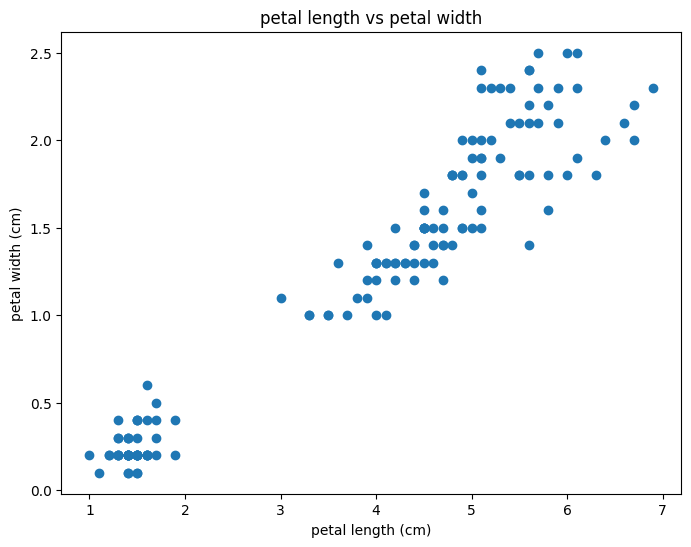

In [109]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)']
)
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('petal length vs petal width')
plt.show()

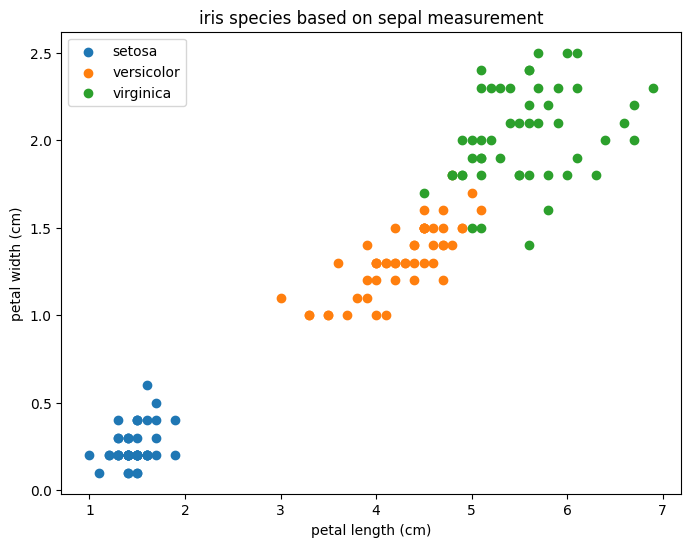

In [110]:
plt.figure(figsize=(8, 6))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=species
    )

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('iris species based on sepal measurement')
plt.legend()
plt.show()

In [111]:
x = iris.data
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )
print("training observations: ", len(x_train))
print("testing observations: ", len(x_test))

training observations:  120
testing observations:  30


In [112]:
model = KNeighborsClassifier(n_neighbors=3)


In [113]:
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [114]:
y_pred=model.predict(x_test)
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [115]:
y_pred=model.predict(x_test)
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [116]:
print('actual: ')
print(y_test)

print('\nPredicted: ')
print(y_pred)

actual: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [117]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  1.0


In [118]:
new_flower = [[6.0,2.7,5.1,1.6]]

In [119]:
prediction=model.predict(new_flower)
print(
"predicted species: ",
       iris.target_names[prediction[0]]
       )

predicted species:  virginica


In [120]:
probabilities= model.predict_proba(new_flower)
print(probabilities)

[[0.         0.33333333 0.66666667]]


In [121]:
for species, probabity in zip(
    iris.target_names,
    probabilities[0]
    ):
    print(f"{species}: {probabity:.2%}")


setosa: 0.00%
versicolor: 33.33%
virginica: 66.67%


In [128]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"k={k}: accuracy={accuracy:.2f}")

k=1: accuracy=0.97
k=3: accuracy=1.00
k=5: accuracy=1.00
k=7: accuracy=0.97
k=9: accuracy=1.00


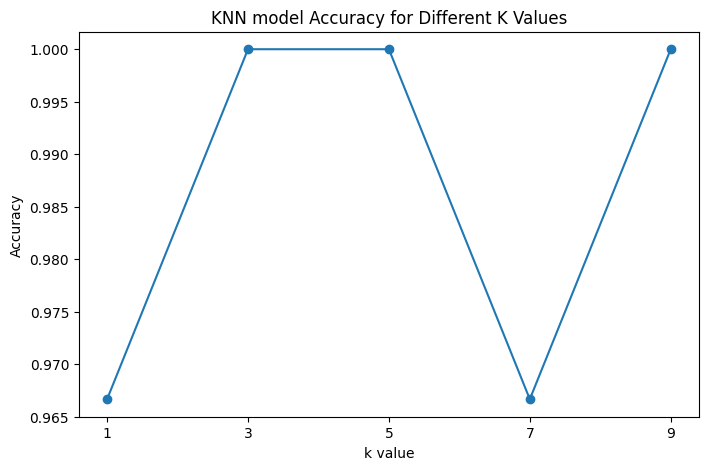

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker='o',
    )
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('KNN model Accuracy for Different K Values')
plt.xticks(k_values)
plt.show()

In [124]:
results = pd.DataFrame({
    'actual': iris.target_names[y_test],
    'predicted': iris.target_names[y_pred],

    })
results.head(10)

,actual,predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [125]:
results["correct"] = (
    results["actual"] == results["predicted"]
)
results.head(10)

,actual,predicted,correct
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True
